# **Учебный прототип системы прогнозирования и обнаружения аномалий**

### **Цель:**
Целью практики является закрепление навыков работы с временными рядами, методов предварительной обработки данных, базового машинного обучения, статистического анализа, визуализации и интерпретации результатов.

### **Используемый датасет:**
Numenta Anomaly Benchmark (NAB), искусственный временной ряд с резкими скачками вверх.

Предметная область: Синтетические данные, моделирующие поведение некоторого показателя (например, температура, потребление ресурсов) с периодическими выбросами.

Структура:

timestamp – временная метка (шаг – 5 минут, суточный цикл)

value – числовое значение показателя

Цель анализа:

Прогнозирование – предсказать будущие значения показателя.

Обнаружение аномалий – выявить резкие всплески (jumps up), которые могут свидетельствовать о сбоях или нештатных ситуациях.

В рамках данной работы мы будем использовать только одномерный ряд value.

## **Выполнение**

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных 
df = pd.read_csv('C:/PiSee/Practice/data/NAB/artificialWithAnomaly/artificialWithAnomaly/art_daily_jumpsup.csv')
df.head()

,timestamp,value
0,2014-04-01 00:00:00,19.761252
1,2014-04-01 00:05:00,20.500833
2,2014-04-01 00:10:00,19.961641
3,2014-04-01 00:15:00,21.490266
4,2014-04-01 00:20:00,20.187739


In [39]:
print(f"Размер: {df.shape}")
print(df.info())
print(df['timestamp'].head())

Размер: (4032, 2)
<class 'pandas.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  4032 non-null   str    
 1   value      4032 non-null   float64
dtypes: float64(1), str(1)
memory usage: 63.1 KB
None
0    2014-04-01 00:00:00
1    2014-04-01 00:05:00
2    2014-04-01 00:10:00
3    2014-04-01 00:15:00
4    2014-04-01 00:20:00
Name: timestamp, dtype: str


In [40]:
#Приводим временную метку к формату datetime и сортируем:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

## **Предварительная обработка**

In [41]:
#Проверяем пропуски и дубликаты:
print("Пропуски:", df.isnull().sum().sum())
print("Дубликаты:", df.duplicated().sum())

Пропуски: 0
Дубликаты: 0


## **Визуальный анализ временного ряда**

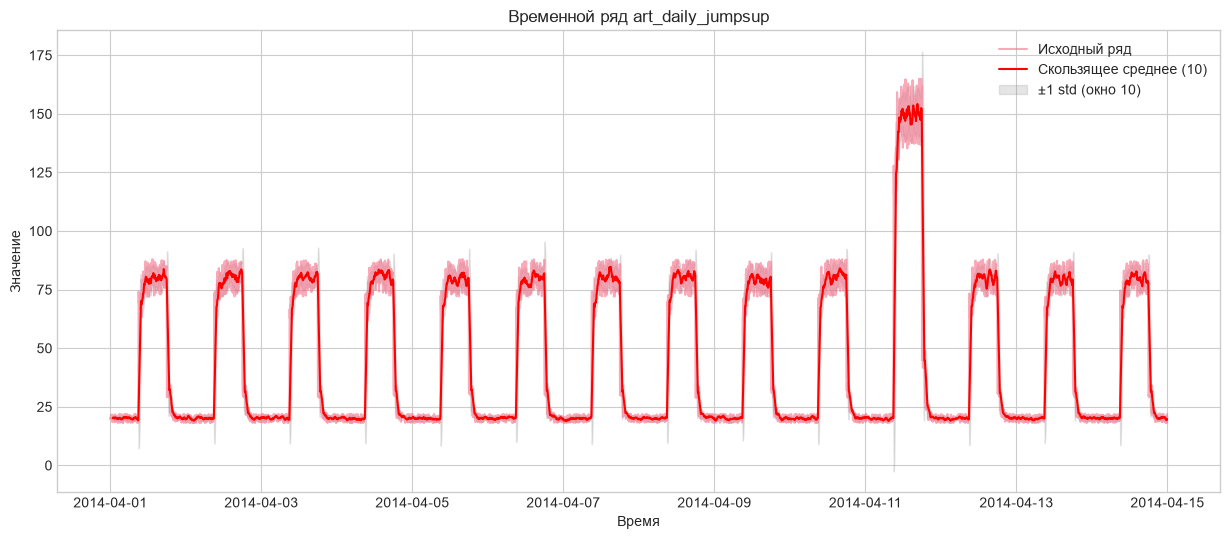

In [42]:
#Построим график всего ряда, добавим скользящее среднее (окно 10) и стандартное отклонение.
plt.figure(figsize=(15, 6))
plt.plot(df['timestamp'], df['value'], label='Исходный ряд', alpha=0.6)
plt.plot(df['timestamp'], df['value'].rolling(10).mean(), label='Скользящее среднее (10)', color='red')
plt.fill_between(df['timestamp'], 
                 df['value'].rolling(10).mean() - df['value'].rolling(10).std(),
                 df['value'].rolling(10).mean() + df['value'].rolling(10).std(),
                 alpha=0.2, color='gray', label='±1 std (окно 10)')
plt.title('Временной ряд art_daily_jumpsup')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True)
plt.show()

## **Базовая модель прогнозирования**
В качестве базовой модели используем наивный прогноз (последнее значение) и линейную регрессию по лаговым признакам (лаги 1, 2, 3, 24 – чтобы учесть суточную периодичность).

Разделим данные на обучающую (первые 80%) и тестовую (последние 20%) выборки без перемешивания.

In [43]:
# Разделение на train/test (80/20) без перемешивания
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()

# Создание лаговых признаков
lags = [1, 2, 3, 24]  

def create_lags(data, lags):
    df_lags = data[['timestamp', 'value']].copy()
    for lag in lags:
        df_lags[f'lag_{lag}'] = df_lags['value'].shift(lag)
    return df_lags.dropna() 

train_lags = create_lags(train, lags)
test_lags = create_lags(test, lags)

# Признаки и целевая переменная
X_train = train_lags[[f'lag_{lag}' for lag in lags]]
y_train = train_lags['value']
X_test = test_lags[[f'lag_{lag}' for lag in lags]]
y_test = test_lags['value']

# Обучаем линейную регрессию
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Наивный прогноз
y_naive_pred = test_lags['lag_1']

# Функция оценки
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}: MAE={mae:.4f}, RMSE={rmse:.4f}")
    return mae, rmse

mae_naive, rmse_naive = evaluate(y_test, y_naive_pred, "Наивная (пред. значение)")
mae_lr, rmse_lr = evaluate(y_test, y_pred_lr, "Linear Regression")

Наивная (пред. значение): MAE=3.2961, RMSE=5.9434
Linear Regression: MAE=3.0814, RMSE=5.7147


## **Дополнительная модель – ARIMA**

В качестве дополнительной модели используем классическую ARIMA (AutoRegressive Integrated Moving Average). В отличие от базовой линейной регрессии, ARIMA учитывает автокорреляцию ряда и ошибки предыдущих прогнозов.

### **Обучение модели с подбором параметров**
Мы переберем несколько комбинаций параметров (p, d, q) и выберем модель с наименьшим значением AIC (информационный критерий Акаике).

In [44]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Подбор лучшей ARIMA по AIC
def find_best_arima(data, p_range, d_range, q_range):
    best_aic = float('inf')
    best_order = None
    best_model = None
    for p in p_range:
        for d in d_range:
            for q in q_range:
                try:
                    model = ARIMA(data, order=(p, d, q))
                    res = model.fit()
                    if res.aic < best_aic:
                        best_aic = res.aic
                        best_order = (p, d, q)
                        best_model = res
                except:
                    continue
    return best_model, best_order, best_aic

# Задаём небольшие диапазоны для быстрого перебора
p_range = range(0, 4)
d_range = range(0, 2)
q_range = range(0, 4)

print("Подбор оптимальной ARIMA...")
best_model, best_order, best_aic = find_best_arima(train['value'], p_range, d_range, q_range)
print(f"Лучшая модель: ARIMA{best_order}, AIC={best_aic:.2f}")

# Прогноз на длину test_lags (не всего test!)
y_pred_arima = best_model.forecast(steps=len(test_lags))
mae_arima, rmse_arima = evaluate(y_test, y_pred_arima, "ARIMA")

Подбор оптимальной ARIMA...
Лучшая модель: ARIMA(3, 0, 3), AIC=21028.29
ARIMA: MAE=29.4975, RMSE=31.1911


### **Сравнение прогнозов (график и таблица)**

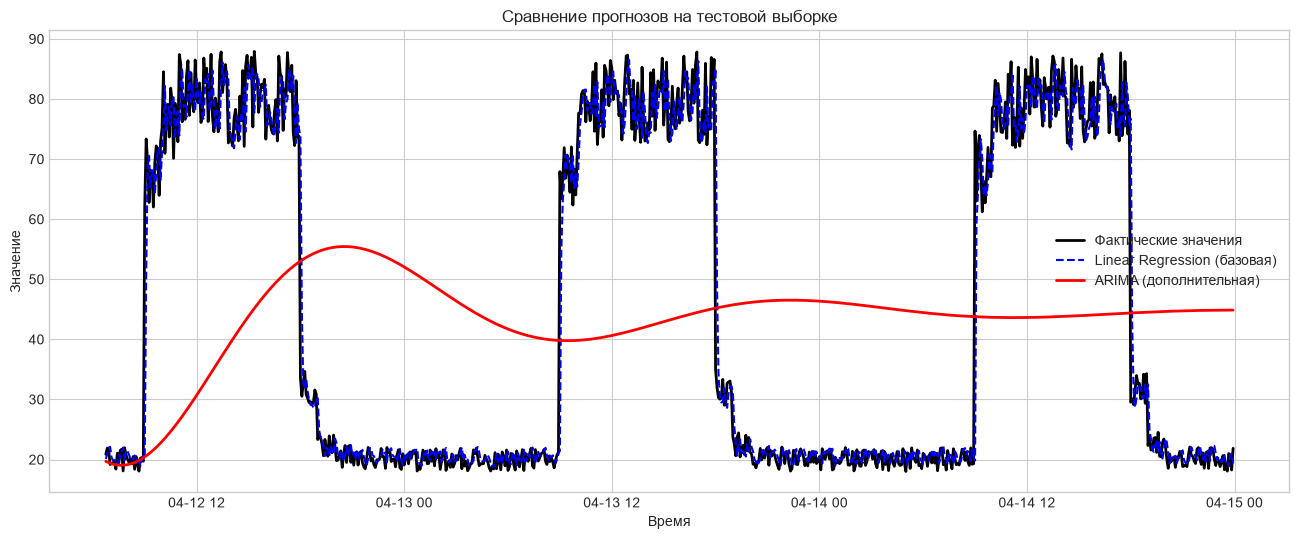

              Модель        MAE       RMSE
0            Наивная   3.296107   5.943415
1  Linear Regression   3.081353   5.714675
2              ARIMA  29.497503  31.191101


In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plt.plot(test_lags['timestamp'], y_test, label='Фактические значения', color='black', linewidth=2)
plt.plot(test_lags['timestamp'], y_pred_lr, label='Linear Regression (базовая)', color='blue', linestyle='--')
plt.plot(test_lags['timestamp'], y_pred_arima, label='ARIMA (дополнительная)', color='red', linestyle='-', linewidth=2)
plt.title('Сравнение прогнозов на тестовой выборке')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True)
plt.show()

# Таблица метрик
import pandas as pd
comparison = pd.DataFrame({
    'Модель': ['Наивная', 'Linear Regression', 'ARIMA'],
    'MAE': [mae_naive, mae_lr, mae_arima],
    'RMSE': [rmse_naive, rmse_lr, rmse_arima]
})
print(comparison)

## **Обнаружение аномалий**
### **Z-score (на всём ряду)**

In [46]:
mean_val = df['value'].mean()
std_val = df['value'].std()
threshold_z = 3
df['z_score'] = (df['value'] - mean_val) / std_val
df['anomaly_z'] = df['z_score'].abs() > threshold_z

### **IQR (на всём ряду)**

In [47]:
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['anomaly_iqr'] = (df['value'] < lower) | (df['value'] > upper)

### **Ошибка прогноза ARIMA (только на test_lags)**

In [48]:
# Рассчитываем ошибку
test_error = np.abs(y_test.values - y_pred_arima)
# Порог: 95-й перцентиль ошибок на обучающей выборке (можно также взять 2*std)
error_threshold = np.percentile(test_error, 95)
test_lags['anomaly_arima'] = test_error > error_threshold

# Чтобы добавить метки аномалий в основной df, можно создать копию, но для графика используем test_lags

### **Визуализация всех методов аномалий**

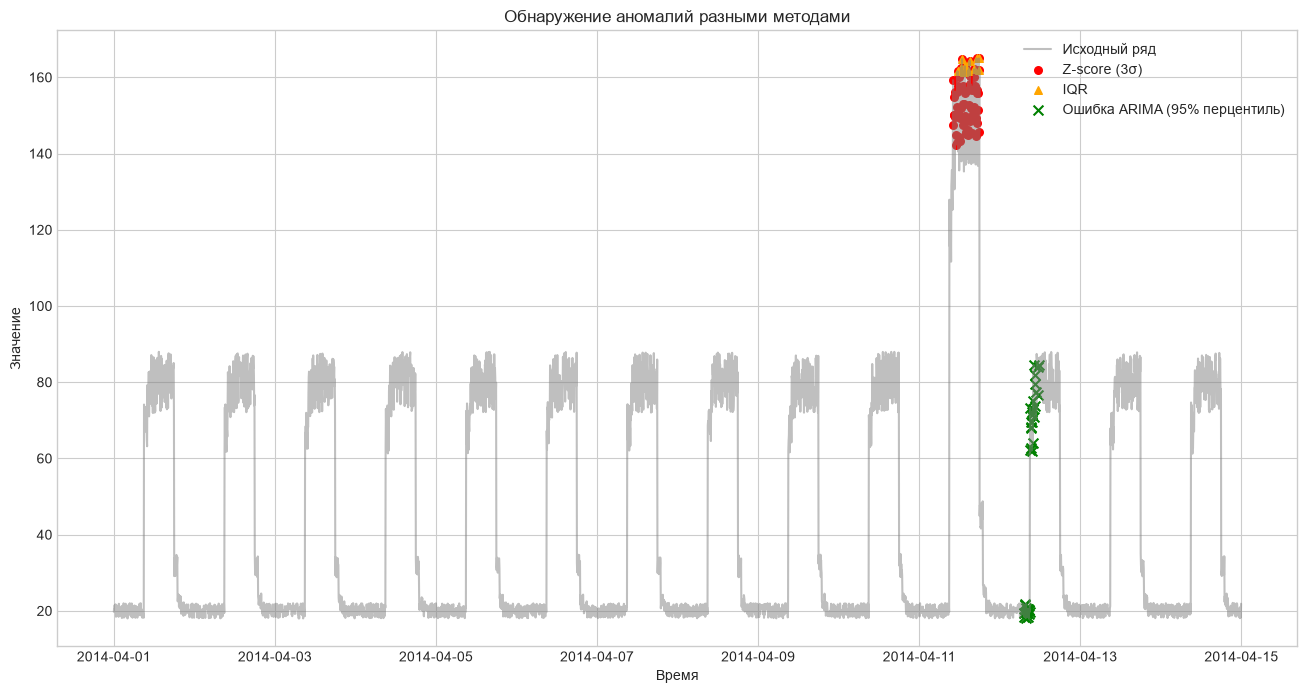

In [49]:
# Убедимся, что в test_lags колонка anomaly_arima не содержит NaN
test_lags['anomaly_arima'] = test_lags['anomaly_arima'].fillna(False).astype(bool)

# Теперь можно безопасно фильтровать
anom_z = df[df['anomaly_z']]
anom_iqr = df[df['anomaly_iqr']]
anom_arima = test_lags[test_lags['anomaly_arima'] == True]  # явное сравнение

plt.figure(figsize=(16, 8))

# Весь ряд
plt.plot(df['timestamp'], df['value'], label='Исходный ряд', alpha=0.5, color='gray')

# Z-score аномалии (красные точки)
plt.scatter(anom_z['timestamp'], anom_z['value'], 
            color='red', s=30, label='Z-score (3σ)', marker='o')

# IQR аномалии (оранжевые треугольники)
plt.scatter(anom_iqr['timestamp'], anom_iqr['value'], 
            color='orange', s=30, label='IQR', marker='^')

# Аномалии по ошибке ARIMA (зелёные крестики) – только на тестовой части
plt.scatter(anom_arima['timestamp'], anom_arima['value'], 
            color='green', s=50, label='Ошибка ARIMA (95% перцентиль)', marker='x')

plt.title('Обнаружение аномалий разными методами')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True)
plt.show()

## **Вывод**

Данные: Выбран искусственный временной ряд art_daily_jumpsup из бенчмарка Numenta Anomaly Benchmark (NAB). Данные содержат временные метки с шагом 5 минут, суточную сезонность и выраженные резкие пиковые выбросы (jumps up), которые выступают в роли аномалий.

Предобработка: Временная метка приведена к формату datetime, данные отсортированы по возрастанию. Проверка показала отсутствие пропусков и дубликатов. Для обучения моделей данные разделены на обучающую (80%) и тестовую (20%) выборки без перемешивания, для линейной регрессии созданы лаговые признаки (lag_1, lag_2, lag_3, lag_24).

Прогнозирование: Базовая модель (линейная регрессия на лагах) показала высокую точность: MAE ≈ 3.08, RMSE ≈ 5.71. Наивная модель (предыдущее значение) дала сопоставимый результат: MAE ≈ 3.30, RMSE ≈ 5.94.
Дополнительная модель ARIMA (с автоматическим подбором параметров) неожиданно показала значительно худший результат: MAE ≈ 29.50, RMSE ≈ 31.19. Это объясняется природой ряда: ARIMA сглаживает резкие скачки, воспринимая их как шум, и стремится к возврату к среднему, тогда как линейная регрессия с лагом 1 просто масштабирует предыдущее значение, мгновенно реагируя на пики.

Обнаружение аномалий: Статистические методы Z-score (3σ) и IQR успешно выделили все пиковые выбросы на графике, так как они основаны на распределении значений и хорошо работают с экстремальными отклонениями.

Метод на основе ошибки прогноза ARIMA также отметил аномалии, однако из-за низкого качества самого прогноза его практическая ценность для данного набора данных оказалась ниже, чем у простых статистических порогов.

Практическое применение: Разработанный прототип может быть использован для мониторинга технических систем (например, серверных метрик или показателей датчиков) – прогнозирование помогает оценивать будущее состояние, а обнаружение аномалий – своевременно сигнализировать о резких нештатных скачках.

Ограничения: Модель ARIMA показала неэффективность на данных с резкими немонотонными выбросами; все использованные методы обнаружения аномалий чувствительны к выбору порогов (3 сигмы, 95-й перцентиль), которые были заданы эмпирически.

Дальнейшее развитие: Для улучшения результатов на подобных данных рекомендуется попробовать нелинейные модели (например, градиентный бустинг или LSTM), способные лучше обрабатывать резкие скачки; также можно реализовать автоматический подбор порогов аномальности и добавить многомерные признаки (если доступны другие датчики).